In [173]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../churn.db")

### VISÃO GERAL DO PROBLEMA

##### Taxa de churn geral

In [174]:
query = """
SELECT COUNT(*) AS total_clientes,
    SUM(Churn) AS clientes_churn,
    ROUND(AVG(Churn) * 100, 2) AS churn_rate_percent
FROM customers;
"""

df = pd.read_sql(query, conn)
df

,total_clientes,clientes_churn,churn_rate_percent
0,7043,1869,26.54


### ANÁLISE DE PERFIL

##### Churn por tipo de contrato

In [175]:
query = """
SELECT 
    Contract,
    COUNT(*) AS total,
    ROUND(AVG(Churn) * 100, 2) AS churn_rate
FROM customers
GROUP BY Contract
ORDER BY churn_rate DESC;
"""

df = pd.read_sql(query, conn)
df

,Contract,total,churn_rate
0,Month-to-month,3875,42.71
1,One year,1473,11.27
2,Two year,1695,2.83


In [176]:
import matplotlib.pyplot as plt


def plot_churn_pie(
    data,
    values_col,
    labels=None,
    title='Churn por tipo de contrato',
    colors=["#961616", "#274ECE", '#474935'],
    pctdistance=0.8
):
    fig, ax = plt.subplots(figsize=(8, 6))

    wedges, texts, autotexts = ax.pie(
        data[values_col],
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white'},
        colors=colors,
        pctdistance=pctdistance
    )

    # Estilo dos labels
    for text in texts:
        text.set_fontsize(14)
        text.set_fontweight('bold')
        text.set_color('black')

    # Estilo das porcentagens
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(14)

    ax.set_title(
        title,
        fontsize=18,
        fontweight='bold',
        y=1.05
    )

    plt.axis('equal')
    plt.show()

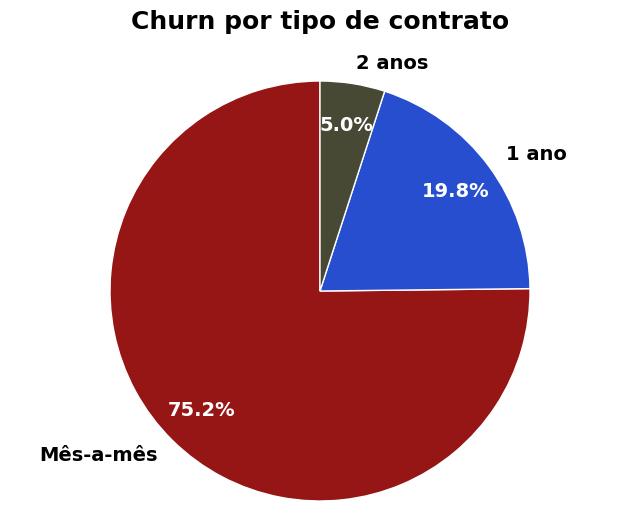

In [177]:
plot_churn_pie(
    df,
    values_col='churn_rate',
    labels=['Mês-a-mês', '1 ano', '2 anos']
)

Clientes com contratos "Month-to-month" têm a taxa de churn mais alta, como não possuem compromisso a longo prazo indica maior risco de cancelamento. Contrato de 2 anos mostra churn significativamente menor, indicando comprometimento maior.

**AÇÃO: Converter clientes para contratos mais longos reduz risco de perda, talvez cobrando menos nesses planos em comparação ao de mês a mês.**

##### Churn por tempo de cliente (tenure)

In [178]:
query = """
SELECT 
    CASE 
        WHEN tenure < 12 THEN '0-1 ano'
        WHEN tenure < 24 THEN '1-2 anos'
        ELSE '2+ anos'
    END AS faixa_tempo,
    COUNT(*) AS total,
    ROUND(AVG(Churn) * 100, 2) AS churn_rate
FROM customers
GROUP BY faixa_tempo
ORDER BY churn_rate DESC;
"""

df = pd.read_sql(query, conn)
df

,faixa_tempo,total,churn_rate
0,0-1 ano,2069,48.28
1,1-2 anos,1047,29.51
2,2+ anos,3927,14.29


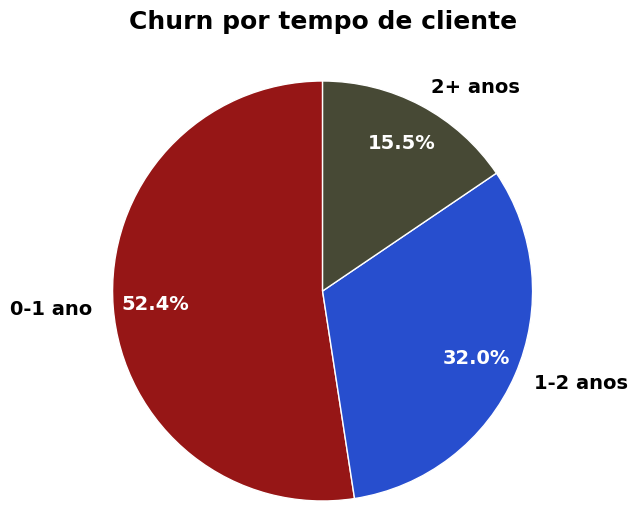

In [179]:
plot_churn_pie(
    df,
    values_col='churn_rate',
    labels=df['faixa_tempo'],
    title='Churn por tempo de cliente'
)

- Clientes com menos de 1 ano são o grupo mais vulnerável
- A janela de "0-12 meses" é crítica para retenção
  
**Ação: Implementar programas de onboarding e suporte agressivo nos primeiros meses**

### SERVIÇOS E COMPORTAMENTO

##### Churn por suporte técnico

In [180]:
query = """
SELECT 
    TechSupport,
    COUNT(*) AS total,
    ROUND(AVG(Churn) * 100, 2) AS churn_rate
FROM customers
GROUP BY TechSupport
ORDER BY churn_rate DESC;
"""

df = pd.read_sql(query, conn)
df

,TechSupport,total,churn_rate
0,No,3473,41.64
1,Yes,2044,15.17
2,No internet service,1526,7.40


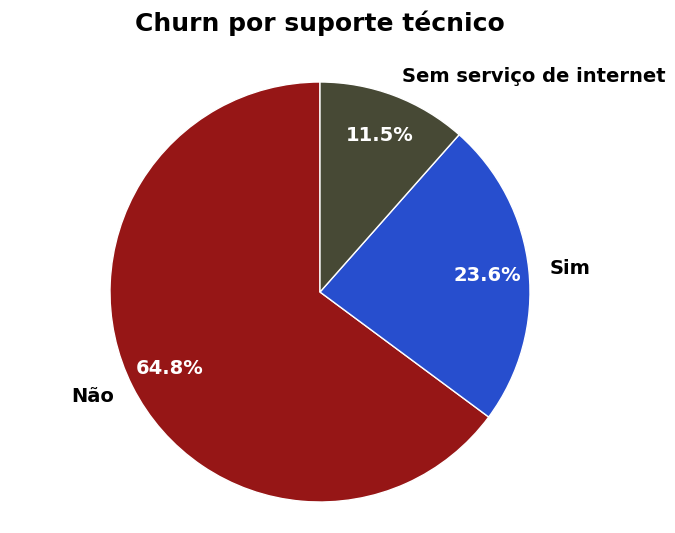

In [181]:
plot_churn_pie(
    df,
    values_col='churn_rate',
    labels=['Não', 'Sim', 'Sem serviço de internet'],
    title='Churn por suporte técnico'
)

Clientes sem suporte técnico provavelmente têm significativamente maior

**Ação: Oferecer suporte técnico reduz significativamente o churn**

##### Churn por tipo de internet

In [182]:
query = """
SELECT InternetService,
    ROUND(AVG(Churn) * 100, 2) AS churn_rate
FROM customers
GROUP BY InternetService
ORDER BY churn_rate DESC;
"""

df = pd.read_sql(query, conn)
df

,InternetService,churn_rate
0,Fiber optic,41.89
1,DSL,18.96
2,No,7.40


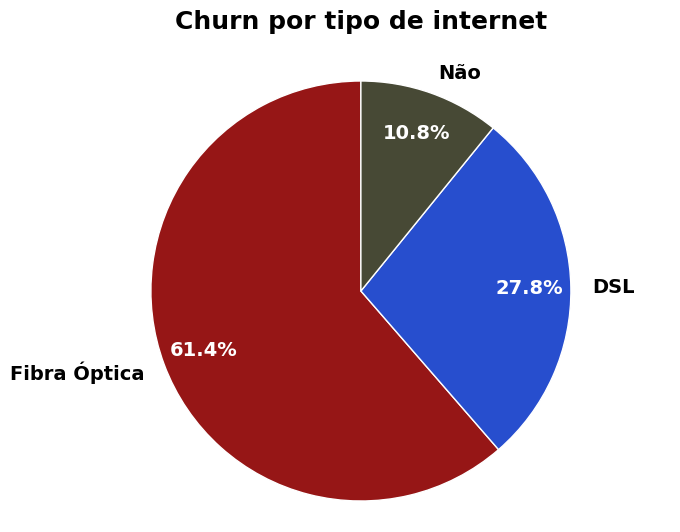

In [183]:
plot_churn_pie(
    df,
    values_col='churn_rate',
    labels=['Fibra Óptica', 'DSL', 'Não'],
    title='Churn por tipo de internet'
)

Fibra óptica possui pior retenção, possíveis causas:
- Preço mais alto
- Expectativa maior (cliente exige mais qualidade)
- Problemas de estabilidade ou instalação
- Público mais exigente e com mais opções no mercado

Logo clientes premium (fibra) são os mais propensos a cancelar se a experiência não for perfeita.

**AÇÃO: Foco total em clientes de fibra: Monitorar experiência (velocidade, quedas), suporte mais rápido e roatividade (antes de reclamar)**

##### Churn por método de pagamento

In [184]:
query = """
SELECT 
    PaymentMethod,
    ROUND(AVG(Churn) * 100, 2) AS churn_rate
FROM customers
GROUP BY PaymentMethod
ORDER BY churn_rate DESC;
"""

df = pd.read_sql(query, conn)
df

,PaymentMethod,churn_rate
0,Electronic check,45.29
1,Mailed check,19.11
2,Bank transfer (automatic),16.71
3,Credit card (automatic),15.24


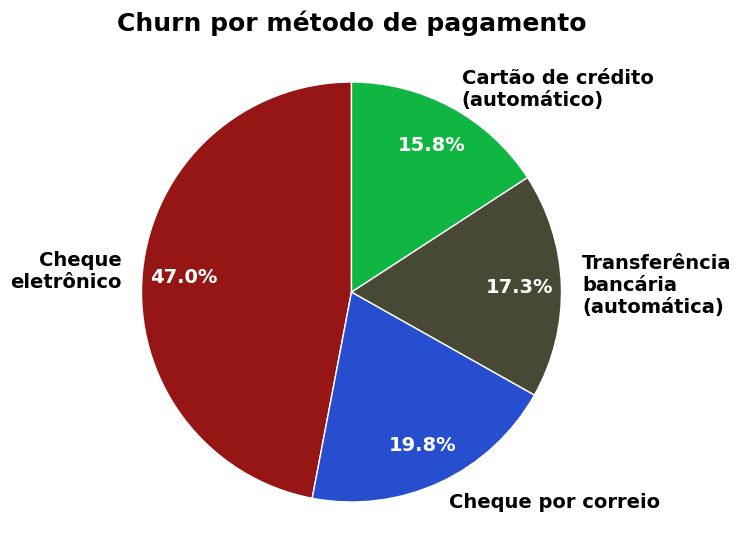

In [189]:
plot_churn_pie(
    df,
    values_col='churn_rate',
    labels=['Cheque\neletrônico', 'Cheque por correio', 'Transferência\nbancária\n(automática)', 'Cartão de crédito\n(automático)'],
    title='Churn por método de pagamento',
    colors=["#961616", "#274ECE", '#474935', "#0FB641"]
)

- Métodos automáticos (débito/cartão) correlacionam com melhor retenção
- Métodos manuais (cheque) indicam menor engajamento

**AÇÃO: Facilitar/incentivar pagamento automático**

##### INSIGHT: Perfil de alto risco

In [ ]:
query = """
SELECT *
FROM customers
WHERE 
    Contract = 'Month-to-month'
    AND tenure < 12
    AND Churn = 1;
"""

df = pd.read_sql(query, conn)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,4190-MFLUW,Female,0,Yes,Yes,10,Yes,No,DSL,No,...,Yes,Yes,No,No,Month-to-month,No,Credit card (automatic),55.20,528.35,1
4,8779-QRDMV,Male,1,No,No,1,No,No phone service,DSL,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,5482-NUPNA,Female,0,No,No,4,Yes,No,DSL,Yes,...,No,Yes,No,No,Month-to-month,Yes,Mailed check,60.40,272.15,1
987,1122-JWTJW,Male,0,Yes,Yes,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,70.65,70.65,1
988,8775-CEBBJ,Female,0,No,No,9,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),44.20,403.35,1
989,6894-LFHLY,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,75.75,75.75,1


**Padrão a evitar: contratos curtos com clientes novos**